In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fixed typo: liner_model -> linear model
# Added specific imports or import all with *
from sklearn.linear_model import LinearRegression  #You can add other models you need
from sklearn.metrics import mean_squared_error,r2_score
#Fixed typo: matrics -> metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df=pd.read_csv('boston_data.csv')
df.head()

,ID,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,4,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
3,5,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
4,7,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9


In [3]:
df.shape

(333, 12)

In [4]:
df.info

<bound method DataFrame.info of       ID  indus  chas    nox     rm   age     dis  rad  tax  ptratio  lstat  \
0      1   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   4.98   
1      2   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   9.14   
2      4   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   2.94   
3      5   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   5.33   
4      7   7.87     0  0.524  6.012  66.6  5.5605    5  311     15.2  12.43   
..   ...    ...   ...    ...    ...   ...     ...  ...  ...      ...    ...   
328  500   9.69     0  0.585  5.569  73.5  2.3999    6  391     19.2  15.10   
329  502  11.93     0  0.573  6.593  69.1  2.4786    1  273     21.0   9.67   
330  503  11.93     0  0.573  6.120  76.7  2.2875    1  273     21.0   9.08   
331  504  11.93     0  0.573  6.976  91.0  2.1675    1  273     21.0   5.64   
332  506  11.93     0  0.573  6.030  80.8  2.5050    1  273     21.0   7.88   

     medv  
0    24

In [8]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
328    False
329    False
330    False
331    False
332    False
Length: 333, dtype: bool

In [10]:
df.describe()

,ID,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000
mean,250.951952,11.293483,0.060060,0.557144,6.265619,68.226426,3.709934,9.633634,409.279279,18.448048,12.515435,22.768769
std,147.859438,6.998123,0.237956,0.114955,0.703952,28.133344,1.981123,8.742174,170.841988,2.151821,7.067781,9.173468
min,1.000000,0.740000,0.000000,0.385000,3.561000,6.000000,1.129600,1.000000,188.000000,12.600000,1.730000,5.000000
25%,123.000000,5.130000,0.000000,0.453000,5.884000,45.400000,2.122400,4.000000,279.000000,17.400000,7.180000,17.400000
50%,244.000000,9.900000,0.000000,0.538000,6.202000,76.700000,3.092300,5.000000,330.000000,19.000000,10.970000,21.600000
75%,377.000000,18.100000,0.000000,0.631000,6.595000,93.800000,5.116700,24.000000,666.000000,20.200000,16.420000,25.000000
max,506.000000,27.740000,1.000000,0.871000,8.725000,100.000000,10.710300,24.000000,711.000000,21.200000,37.970000,50.000000


In [11]:
df.isnull().sum()

ID         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
lstat      0
medv       0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

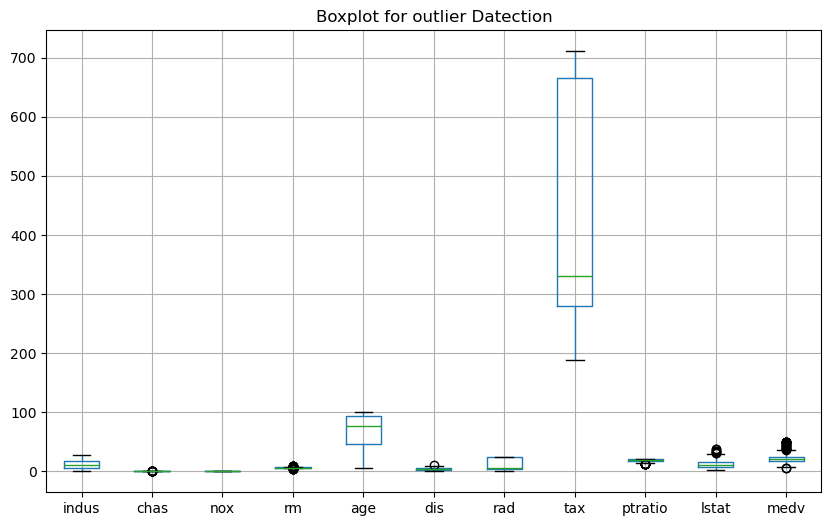

In [12]:
plt.figure(figsize=(10,6))
df.drop('ID', axis=1).boxplot()
plt.title('Boxplot for outlier Datection')
plt.show

In [19]:
Q1 = df["medv"].quantile(0.25)
Q3 = df["medv"].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [20]:
upper

np.float64(36.400000000000006)

In [21]:
lower

np.float64(5.9999999999999964)

In [22]:
df_clean = df[(df["medv"]>=lower) & (df["medv"]<=upper)]
df_clean.shape

(305, 12)

In [24]:
X = df.drop("medv", axis=1)
y = df["medv"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [33]:
y_pred = model.predict(X_test)

In [44]:
mse =mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 score:", r2)

MSE: 24.60555505326478
R2 score: 0.7266000308955687


In [46]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred_rf))


R2: 0.9018451469512312


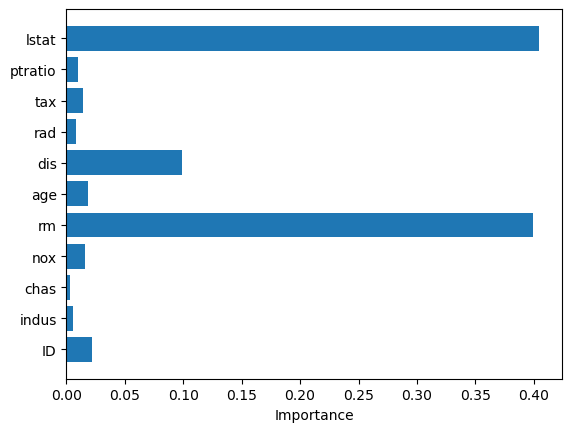

In [47]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

plt.barh(X.columns, importances)
plt.xlabel("Importance")
plt.show()

In [55]:
# example new house data (must match feature order)
new_data = np.array([[ 8, 0.5, 6.5, 5, 4.0, 7, 10, 50,  20, 10, 5]])

# scale it using SAME scaler
new_data_scaled = scaler.transform(new_data)

# predict
prediction = model.predict(new_data_scaled)

print("Predicted price:", prediction)

Predicted price: [69.68106769]
